In [1]:
import cupy as cp
import tensorflow as tf
import matplotlib.pyplot as plt
from model.alexnet import build_alexnet
from core.losses import CategoricalCrossEntropyLoss
from core.optimizers import SGDMomentum
from utils.load_data import load_local_cifar10, preprocess

In [2]:
cifar10_classes = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 
                   'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

In [3]:
(x_train, y_train), (x_test, y_test) = load_local_cifar10('data/cifar-10-batches-py')

In [4]:
NUM_TRAIN = 1000
NUM_VAL = 200

In [5]:
x_train = x_train[:NUM_TRAIN]
y_train = y_train[:NUM_TRAIN]
x_test = x_test[:NUM_VAL]
y_test = y_test[:NUM_VAL]

print(f"Training Data: {x_train.shape}")
print(f"Validation Data: {x_test.shape}")

Training Data: (1000, 32, 32, 3)
Validation Data: (200, 32, 32, 3)


In [6]:
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [7]:
BATCH_SIZE = 16

In [8]:
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = (train_dataset
                 .shuffle(NUM_TRAIN)
                 .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
                 .batch(BATCH_SIZE)
                 .prefetch(tf.data.AUTOTUNE))

In [9]:
val_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
val_dataset = (val_dataset
               .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
               .batch(BATCH_SIZE)
               .prefetch(tf.data.AUTOTUNE))

In [10]:
model = build_alexnet()

In [11]:
model.compile(
    optimizer=SGDMomentum(model.layers, learning_rate=0.001, momentum=0.9),
    criterion=CategoricalCrossEntropyLoss()
)

In [12]:
history = model.fit(train_dataset=train_dataset, epochs=50, val_dataset=val_dataset, patience=5)

Model weights successfully saved to temp_best_weights.pkl
Epoch [1/50] | Train Loss: 2.4970 | Train Acc: 0.0900 | Val Loss: 2.2824 | Val Acc: 0.1500 (Improved!)
Model weights successfully saved to temp_best_weights.pkl
Epoch [2/50] | Train Loss: 2.2084 | Train Acc: 0.1800 | Val Loss: 2.1461 | Val Acc: 0.1800 (Improved!)
Epoch [3/50] | Train Loss: 2.1496 | Train Acc: 0.1890 | Val Loss: 2.2486 | Val Acc: 0.1850 (Patience: 1/5)
Model weights successfully saved to temp_best_weights.pkl
Epoch [4/50] | Train Loss: 2.0813 | Train Acc: 0.2350 | Val Loss: 2.1000 | Val Acc: 0.2350 (Improved!)
Epoch [5/50] | Train Loss: 1.9815 | Train Acc: 0.2670 | Val Loss: 2.3495 | Val Acc: 0.2150 (Patience: 1/5)
Model weights successfully saved to temp_best_weights.pkl
Epoch [6/50] | Train Loss: 1.9378 | Train Acc: 0.2950 | Val Loss: 1.9399 | Val Acc: 0.3050 (Improved!)
Epoch [7/50] | Train Loss: 1.8588 | Train Acc: 0.3110 | Val Loss: 2.0667 | Val Acc: 0.2050 (Patience: 1/5)
Model weights successfully saved to

In [13]:
model.save_weights("alexnet_cifar10_weights.pkl")

Model weights successfully saved to alexnet_cifar10_weights.pkl


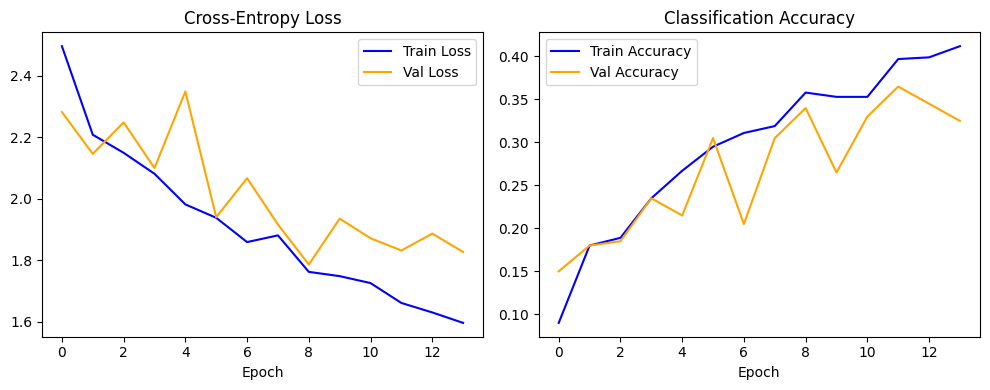

In [14]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
if history['val_loss']:
    plt.plot(history['val_loss'], label='Val Loss', color='orange')
plt.title('Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy', color='blue')
if history['val_acc']:
    plt.plot(history['val_acc'], label='Val Accuracy', color='orange')
plt.title('Classification Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()